In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set_theme(style="whitegrid")

In [2]:
np.random.seed(42)
n_samples = 2000

# Características del cliente
tenure_months = np.random.randint(1, 72, n_samples)
monthly_charges = np.random.uniform(20, 120, n_samples)
support_tickets = np.random.randint(0, 8, n_samples)
# 1: Contrato Mensual, 0: Contrato Anual
contract_type = np.random.choice([0, 1], size=n_samples, p=[0.4, 0.6]) 

# Lógica del Churn: Más tickets, menos tiempo y contrato mensual aumentan la probabilidad
churn_prob = (support_tickets * 0.15) - (tenure_months * 0.005) + (contract_type * 0.2)
# Convertir a binario (1: Churn, 0: Se queda)
churn = np.where(churn_prob + np.random.normal(0, 0.1, n_samples) > 0.5, 1, 0)

df_rf = pd.DataFrame({
    'Tenure_Months': tenure_months,
    'Monthly_Charges': monthly_charges,
    'Support_Tickets': support_tickets,
    'Is_Monthly_Contract': contract_type,
    'Churn': churn
})

print(df_rf['Churn'].value_counts(normalize=True))
df_rf.head()

Churn
0    0.513
1    0.487
Name: proportion, dtype: float64


,Tenure_Months,Monthly_Charges,Support_Tickets,Is_Monthly_Contract,Churn
0,52,45.467062,6,0,1
1,15,104.087158,7,0,1
2,61,23.842635,2,0,0
3,21,110.176199,7,0,1
4,24,66.147746,1,1,0


In [3]:
# Separar features y target
X = df_rf.drop('Churn', axis=1)
y = df_rf['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Instanciar y entrenar (con hiperparámetros para evitar sobreajuste)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Predicciones
y_pred = rf_model.predict(X_test)

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       308
           1       0.90      0.94      0.92       292

    accuracy                           0.92       600
   macro avg       0.92      0.92      0.92       600
weighted avg       0.92      0.92      0.92       600



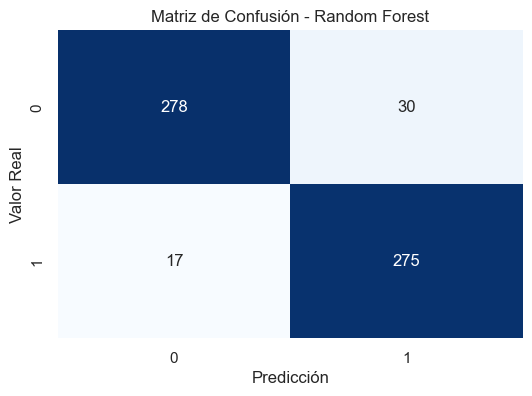

In [4]:
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

# Visualización de la Matriz de Confusión
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

C:\Users\rober\AppData\Local\Temp\ipykernel_11940\1968793181.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


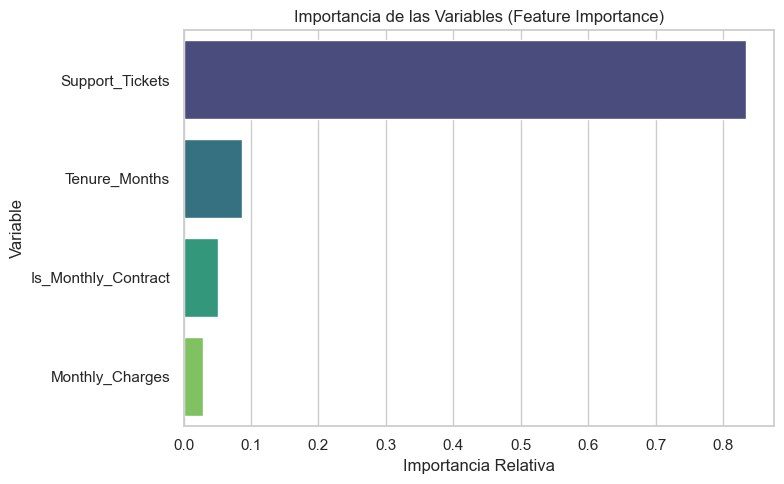

In [5]:
# Extraer la importancia de las variables
feature_importances = rf_model.feature_importances_
features = X.columns

# Crear un DataFrame para visualizar mejor
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Graficar
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Importancia de las Variables (Feature Importance)')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()